In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the data
# (Make sure 'nasa.csv' matches the exact name of your downloaded file)
df = pd.read_csv('nasa.csv')

# 2. Verify the dataset shape to match the report (should be 4687, 40)
print(f"Dataset Shape: {df.shape}")

# 3. Quick look at the target variable imbalance
print("\nClass Imbalance (Hazardous):")
print(df['Hazardous'].value_counts(normalize=True) * 100)

Dataset Shape: (4687, 40)

Class Imbalance (Hazardous):
Hazardous
False    83.891615
True     16.108385
Name: proportion, dtype: float64


In [13]:
# The dataset has diameter in KM, M, Miles, and Feet. We only need one.
# It also has relative velocity in km/s, km/h, and miles/h.
columns_to_drop = [
    'Est Dia in M(min)', 'Est Dia in M(max)', 
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Equatorial Node', # Often blank or irrelevant in this dataset
    'Orbiting Body',   # It's always Earth
    'Neo Reference ID', 'Name', # Identifiers, not predictive features
    'Close Approach Date', 'Orbit Determination Date', 'Equinox', # Dates and strings
    'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(miles)' # Redundant distance metrics
]

# Drop the redundant columns
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

print(f"New Dataset Shape after dropping redundancy: {df_cleaned.shape}")

New Dataset Shape after dropping redundancy: (4687, 23)


In [14]:
# Separate features (X) and target (y)
X = df_cleaned.drop('Hazardous', axis=1)
y = df_cleaned['Hazardous'].astype(int) # Convert boolean True/False to 1/0

# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


C:\Users\Edwar\AppData\Local\Temp\ipykernel_23188\4010921279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hazardous', data=df_cleaned, palette='viridis')


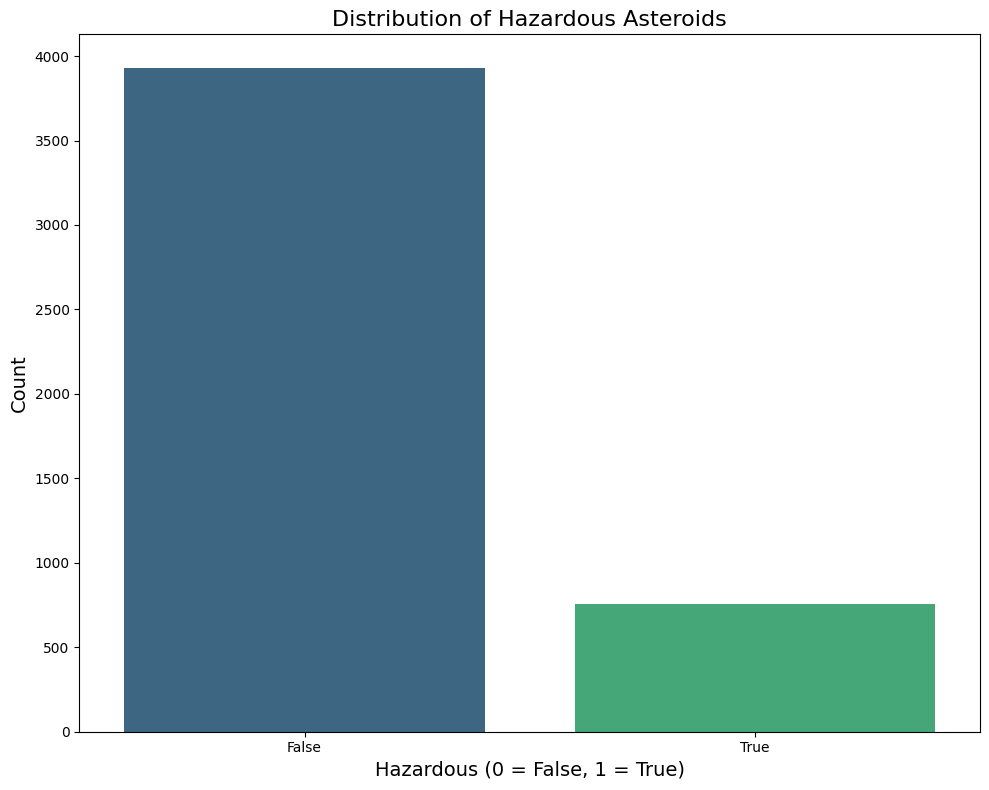

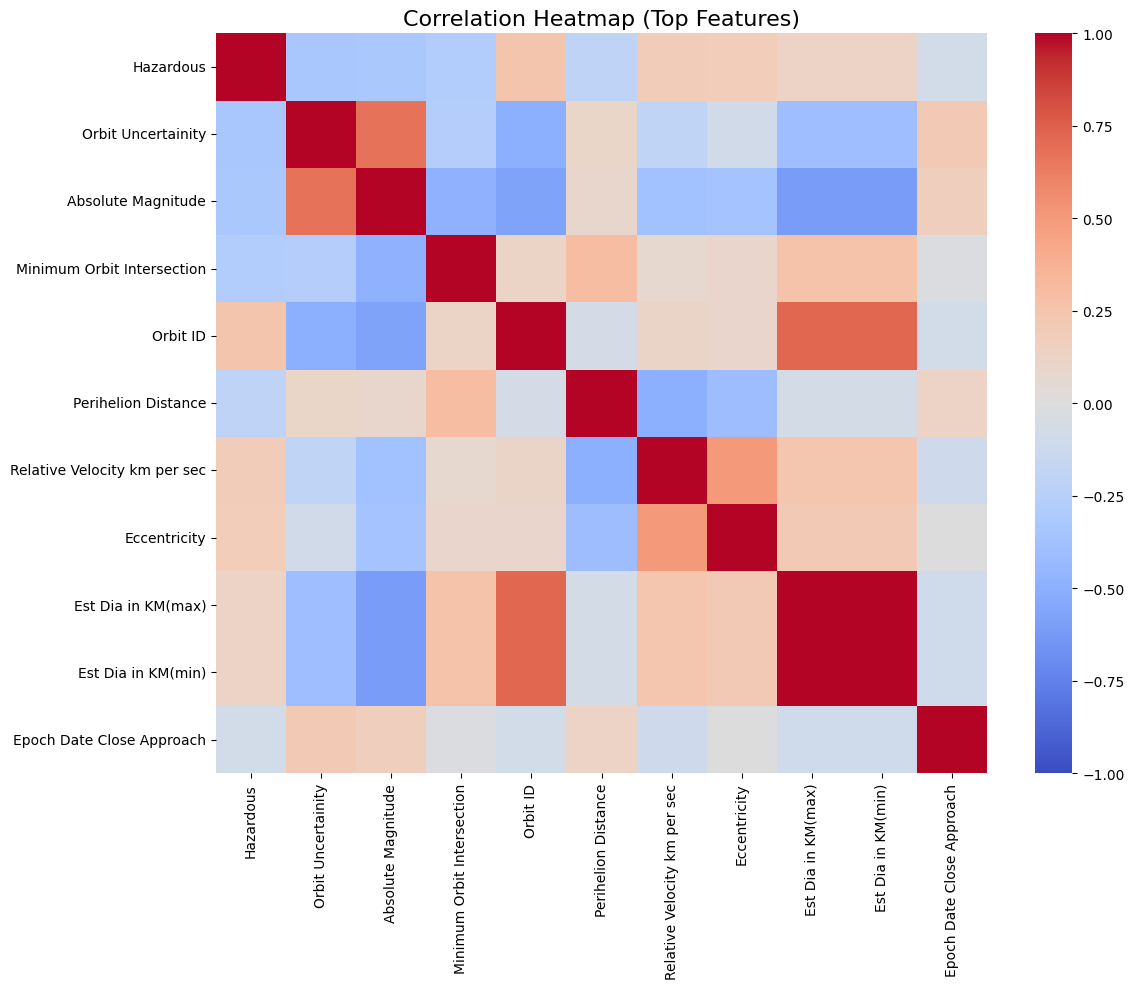

In [15]:
# --- EXPLORATORY DATA ANALYSIS (VISUALS) ---

# Visual 1: Class Imbalance Bar Chart
plt.figure(figsize=(10, 8)) # Generates a large standalone figure
sns.countplot(x='Hazardous', data=df_cleaned, palette='viridis')
plt.title('Distribution of Hazardous Asteroids', fontsize=16)
plt.xlabel('Hazardous (0 = False, 1 = True)', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.tight_layout()
# Uncomment the line below to automatically save a high-res image to your folder
# plt.savefig('class_imbalance_chart.png', dpi=300) 
plt.show()


# Visual 2: Correlation Heatmap (Top 10 features to avoid clutter)
plt.figure(figsize=(12, 10)) # Generates a separate large figure
# Getting top 10 features most correlated with 'Hazardous'
top_corr_features = df_cleaned.corr()['Hazardous'].abs().sort_values(ascending=False).head(11).index
corr_matrix = df_cleaned[top_corr_features].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Top Features)', fontsize=16)

plt.tight_layout()
# Uncomment the line below to automatically save a high-res image to your folder
# plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()